# Project 01 — Revenue Time Series: Noise vs Signal

## Business question
Daily revenue is volatile. How can we distinguish meaningful changes in performance from normal day-to-day noise?

## Dataset
Online Retail II (transaction-level ecommerce data).

## Approach
1. Load and clean transaction data
2. Aggregate to daily revenue
3. Compare raw daily revenue to a smoothed baseline
4. Define a practical rule to avoid over-reacting to noise


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load data

The CSV uses semicolon delimiters (`;`). We load the file and inspect its structure.


In [2]:
df = pd.read_csv("online_retail_II.csv", sep=";")
df.shape, df.columns


((541910, 8),
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
        'Price', 'Customer ID', 'Country'],
       dtype='str'))

## Parse dates and create revenue

We convert the invoice date to a datetime type and compute revenue as
Quantity × Price.


In [3]:
df = df.rename(columns={"Customer ID": "CustomerID"})

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

df["Revenue"] = df["Quantity"] * df["Price"]

df[["InvoiceDate", "Quantity", "Price", "Revenue"]].head()


,InvoiceDate,Quantity,Price,Revenue
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


## Create clean analysis dataset

We exclude:
- Rows with invalid dates
- Returns and invalid rows (Quantity ≤ 0 or Price ≤ 0)
- Cancellation invoices (invoice IDs starting with "C")

The cleaned dataset is stored separately to preserve the raw data.


In [4]:
df["Invoice"] = df["Invoice"].astype(str)

clean = df[
    df["InvoiceDate"].notna()
    & (df["Quantity"] > 0)
    & (df["Price"] > 0)
    & (~df["Invoice"].str.startswith("C"))
].copy()

clean.shape


(530105, 9)

## Aggregate to daily revenue

We aggregate transaction-level data into one revenue value per calendar day.


In [5]:
daily = (
    clean
    .set_index("InvoiceDate")
    .resample("D")["Revenue"]
    .sum()
    .to_frame()
)

daily.head(10)


,Revenue
InvoiceDate,
2010-12-01,58960.79
2010-12-02,47748.38
2010-12-03,46943.71
2010-12-04,0.00
2010-12-05,31774.95
2010-12-06,54830.46
2010-12-07,99618.20
2010-12-08,45389.98
2010-12-09,53586.18


## Rolling baseline (signal)

A 7-day rolling average smooths short-term volatility and reveals the underlying trend.


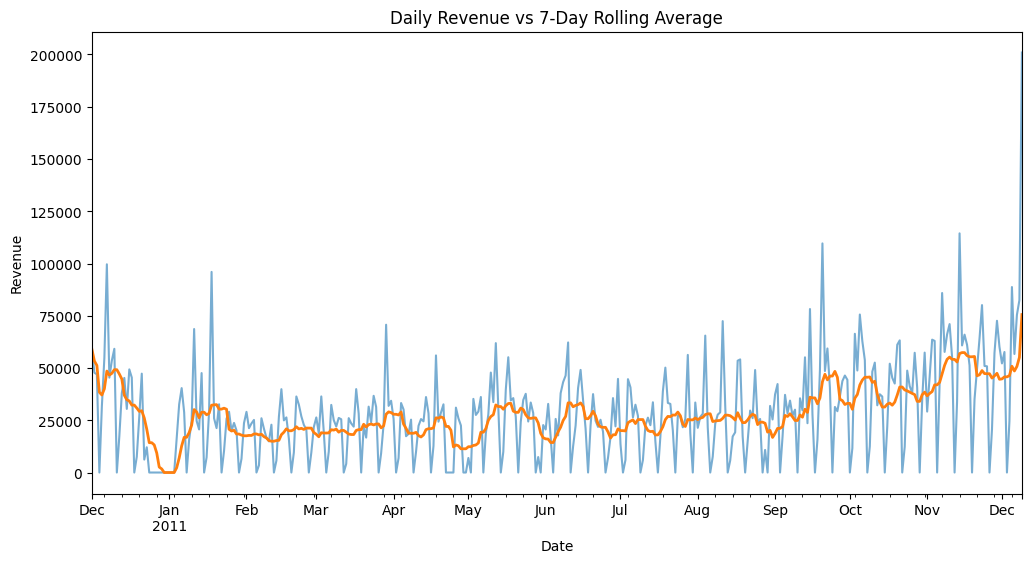

In [6]:
daily["Revenue_7d"] = daily["Revenue"].rolling(7, min_periods=1).mean()

ax = daily["Revenue"].plot(figsize=(12, 6), alpha=0.6)
daily["Revenue_7d"].plot(ax=ax, linewidth=2)

ax.set_title("Daily Revenue vs 7-Day Rolling Average")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.show()



## Quantifying noise vs signal

We compare volatility in:
- Daily percentage changes
- Rolling-average percentage changes

Days with zero revenue are excluded.


In [7]:
nz = daily[daily["Revenue"] > 0].copy()

nz["Daily_pct_change"] = nz["Revenue"].pct_change()
nz["Rolling_pct_change"] = nz["Revenue_7d"].pct_change()

nz[["Daily_pct_change", "Rolling_pct_change"]].dropna().std()


Daily_pct_change      1.099014
Rolling_pct_change    0.168430
dtype: float64

## Defining a “don’t overreact” rule

We measure normal volatility as deviations from the rolling baseline.
Days outside ±2 standard deviations are flagged as unusual.


In [8]:
daily["Residual"] = daily["Revenue"] - daily["Revenue_7d"]

daily["Residual_std_28d"] = (
    daily["Residual"]
    .rolling(28, min_periods=7)
    .std()
)

k = 2
daily["Upper_band"] = daily["Revenue_7d"] + k * daily["Residual_std_28d"]
daily["Lower_band"] = daily["Revenue_7d"] - k * daily["Residual_std_28d"]


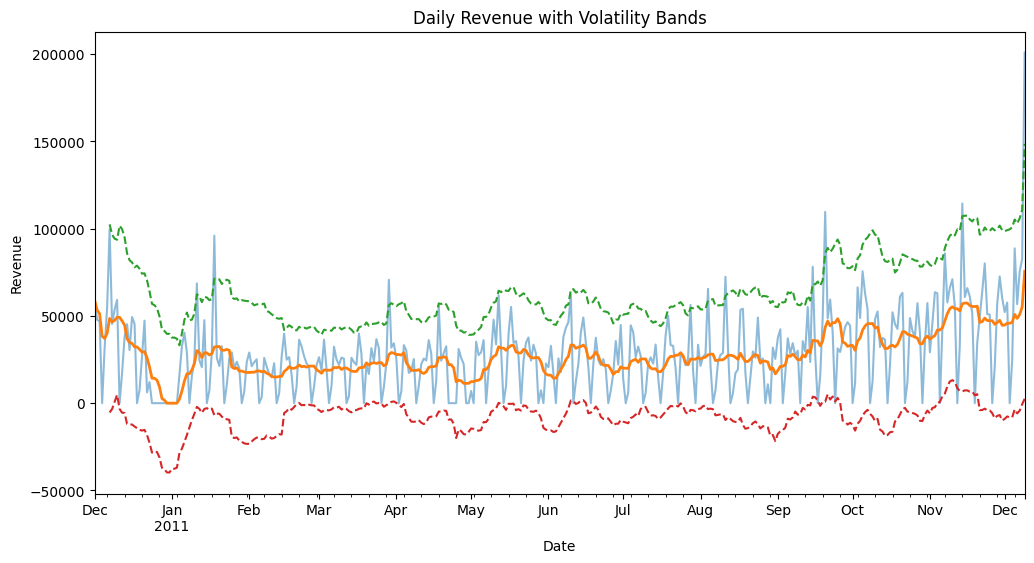

In [9]:
ax = daily["Revenue"].plot(figsize=(12, 6), alpha=0.5)
daily["Revenue_7d"].plot(ax=ax, linewidth=2)
daily["Upper_band"].plot(ax=ax, linestyle="--")
daily["Lower_band"].plot(ax=ax, linestyle="--")

ax.set_title("Daily Revenue with Volatility Bands")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.show()


Note: The lower volatility band may fall below zero during high-volatility periods. This is a statistical artefact of symmetric volatility estimation; revenue itself is bounded at zero.


## How often are days flagged?

We compute the proportion of days outside the ±2σ bands.


In [10]:
valid = daily.dropna(subset=["Upper_band", "Lower_band"])

outside_rate = (
    (valid["Revenue"] > valid["Upper_band"]) |
    (valid["Revenue"] < valid["Lower_band"])
).mean()

outside_rate


np.float64(0.043478260869565216)

## Conclusion

Most daily revenue fluctuations are normal noise.
Only ~4–5% of days fall outside the volatility bands.

Decision rule:
Do not react to single-day movements unless revenue breaks outside the ±2σ band
(or remains outside for multiple consecutive days).
